<a href="https://colab.research.google.com/github/miriamamin1213-ux/FinalModels/blob/main/GPT2CN_Hancock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Downloading...
From: https://drive.google.com/uc?id=1F_kngwHn6KkOQqSwtYXCaF-bT8DZt__Q
To: /content/clinical_data.json
100%|██████████| 810k/810k [00:00<00:00, 75.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KY3NS9q3lfodf-t3g92S1JE3Vqcl6o3F
To: /content/pathological_data.json
100%|██████████| 458k/458k [00:00<00:00, 44.2MB/s]


(763, 49)
Clinical shape: (763, 32)
Pathology shape: (763, 18)
Using device: cuda
Patients: 332

Train class distribution:
0    152
1    113
Name: count, dtype: int64

Test class distribution:
0    39
1    28
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Class weights: tensor([0.8717, 1.1726], device='cuda:0')
Trainable parameters: 100226
Epoch 005, Train=0.7408, Test=0.7075, BA=0.5000, AUC=0.8242, Best Loss Epoch=5, Best BA Epoch=1, Best AUC Epoch=5
Epoch 010, Train=0.6943, Test=0.6940, BA=0.5000, AUC=0.8361, Best Loss Epoch=9, Best BA Epoch=1, Best AUC Epoch=7
Epoch 015, Train=0.6920, Test=0.6940, BA=0.5000, AUC=0.8443, Best Loss Epoch=9, Best BA Epoch=1, Best AUC Epoch=15
Epoch 020, Train=0.6948, Test=0.6900, BA=0.5000, AUC=0.8507, Best Loss Epoch=19, Best BA Epoch=1, Best AUC Epoch=18
Epoch 025, Train=0.6867, Test=0.6903, BA=0.5000, AUC=0.8452, Best Loss Epoch=22, Best BA Epoch=23, Best AUC Epoch=18
Epoch 030, Train=0.6927, Test=0.6864, BA=0.5000, AUC=0.8370, Best Loss Epoch=30, Best BA Epoch=28, Best AUC Epoch=18
Epoch 035, Train=0.6903, Test=0.6905, BA=0.5000, AUC=0.8379, Best Loss Epoch=30, Best BA Epoch=28, Best AUC Epoch=18
Epoch 040, Train=0.6908, Test=0.6844, BA=0.5641, AUC=0.8379, Best Loss Epoch=40, Best BA Epoch=28, Best

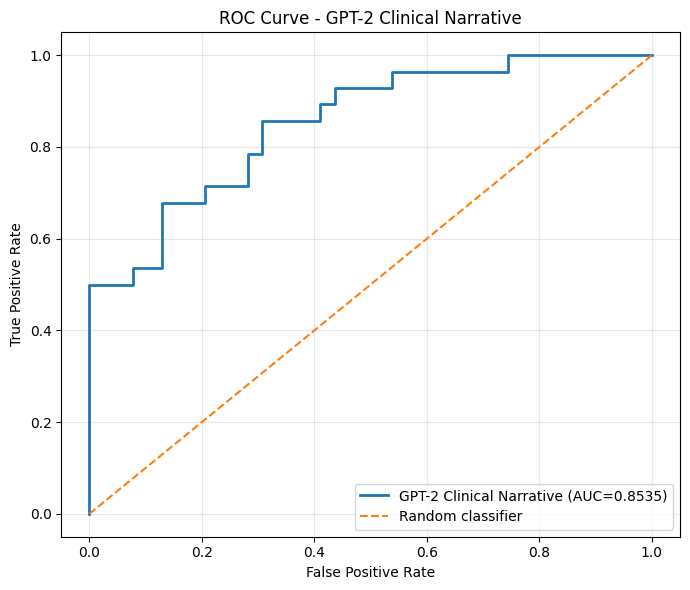

AUC: 0.8535


In [1]:
# ============================================================
# GPT-2 Clinical Narrative - HANCOCK - Seed 42 - No SMOTE
# ============================================================
import os,random,numpy as np,pandas as pd,json
import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,balanced_accuracy_score,f1_score,roc_auc_score,roc_curve
from transformers import GPT2Tokenizer,GPT2Model
import gdown
# ------------------------------------------------------------
# Read Data
# ------------------------------------------------------------
gdown.download(id="1F_kngwHn6KkOQqSwtYXCaF-bT8DZt__Q",output="clinical_data.json",quiet=False)
gdown.download(id="1KY3NS9q3lfodf-t3g92S1JE3Vqcl6o3F",output="pathological_data.json",quiet=False)
with open("clinical_data.json","r") as f:
    clinical=pd.DataFrame(json.load(f))
with open("pathological_data.json","r") as f:
    pathology=pd.DataFrame(json.load(f))
df=clinical.merge(pathology,on="patient_id",how="inner")
print(df.shape)
print("Clinical shape:",clinical.shape)
print("Pathology shape:",pathology.shape)
# ============================================================
# HPV Labels
# ============================================================
df=df[df["hpv_association_p16"].isin(["positive","negative"])].copy()
df["HPV"]=df["hpv_association_p16"].map({"negative":0,"positive":1})
# ============================================================
# GPT2 Hancock Features
# ============================================================
features=[
    "age_at_initial_diagnosis","sex","smoking_status",
    "primarily_metastasis","first_treatment_intent",
    "first_treatment_modality","days_to_first_treatment",
    "adjuvant_treatment_intent","adjuvant_radiotherapy",
    "adjuvant_radiotherapy_modality","adjuvant_systemic_therapy",
    "adjuvant_systemic_therapy_modality",
    "adjuvant_radiochemotherapy","primary_tumor_site",
    "pT_stage","pN_stage","histologic_type",
    "number_of_positive_lymph_nodes",
    "number_of_resected_lymph_nodes","perinodal_invasion",
    "lymphovascular_invasion_L","vascular_invasion_V",
    "perineural_invasion_Pn","resection_status",
    "infiltration_depth_in_mm"
]
# ============================================================
# Narrative Function
# ============================================================
def patient_to_text(row):
    text=(
        f"This patient was diagnosed at age "
        f"{row['age_at_initial_diagnosis']}. "
        f"Sex is {row['sex']}. "
        f"Smoking status is {row['smoking_status']}. "
        f"Primary metastasis status is {row['primarily_metastasis']}. "
        f"Primary tumour site is {row['primary_tumor_site']}. "
        f"Histologic type is {row['histologic_type']}. "
        f"Pathological T stage is {row['pT_stage']}. "
        f"Pathological N stage is {row['pN_stage']}. "
        f"The patient has "
        f"{row['number_of_positive_lymph_nodes']} positive "
        f"lymph nodes and "
        f"{row['number_of_resected_lymph_nodes']} resected "
        f"lymph nodes. "
        f"Perinodal invasion status is "
        f"{row['perinodal_invasion']}. "
        f"Lymphovascular invasion status is "
        f"{row['lymphovascular_invasion_L']}. "
        f"Vascular invasion status is "
        f"{row['vascular_invasion_V']}. "
        f"Perineural invasion status is "
        f"{row['perineural_invasion_Pn']}. "
        f"Resection status is {row['resection_status']}. "
        f"Infiltration depth is "
        f"{row['infiltration_depth_in_mm']} mm. "
        f"First treatment intent was "
        f"{row['first_treatment_intent']}. "
        f"First treatment modality was "
        f"{row['first_treatment_modality']}. "
        f"Days to first treatment was "
        f"{row['days_to_first_treatment']}. "
        f"Adjuvant treatment intent was "
        f"{row['adjuvant_treatment_intent']}. "
        f"Adjuvant radiotherapy was "
        f"{row['adjuvant_radiotherapy']}. "
        f"Adjuvant radiotherapy modality was "
        f"{row['adjuvant_radiotherapy_modality']}. "
        f"Adjuvant systemic therapy was "
        f"{row['adjuvant_systemic_therapy']}. "
        f"Adjuvant systemic therapy modality was "
        f"{row['adjuvant_systemic_therapy_modality']}. "
        f"Adjuvant radiochemotherapy was "
        f"{row['adjuvant_radiochemotherapy']}. "
        f"Predict whether the patient is HPV positive "
        f"or HPV negative."
    )
    return text
# ============================================================
# Reproducibility
# ============================================================
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"]=str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"]=":4096:8"
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True,warn_only=True)
    torch.backends.cudnn.deterministic=True
    torch.backends.cudnn.benchmark=False
    torch.backends.cuda.matmul.allow_tf32=False
    torch.backends.cudnn.allow_tf32=False
SEED=42
seed_everything(SEED)
# ============================================================
# Device
# ============================================================
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:",device)
# ============================================================
# Train-test split
# ============================================================
train_df,test_df=train_test_split(
    df[features+["HPV"]],
    test_size=0.2,
    random_state=SEED,
    stratify=df["HPV"]
)
train_df=train_df.copy()
test_df=test_df.copy()
# ============================================================
# Train-only Missing Value Preprocessing
# ============================================================
for col in features:
    if train_df[col].dtype==object:
        value=train_df[col].mode().iloc[0]
    else:
        value=train_df[col].median()
    train_df[col]=train_df[col].fillna(value)
    test_df[col]=test_df[col].fillna(value)
# ============================================================
# Create GPT2 Text Corpus
# ============================================================
train_texts=train_df.apply(patient_to_text,axis=1).tolist()
test_texts=test_df.apply(patient_to_text,axis=1).tolist()
y_train=train_df["HPV"].tolist()
y_test=test_df["HPV"].tolist()
print("Patients:",len(train_texts)+len(test_texts))
print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts())
print("\nTest class distribution:")
print(pd.Series(y_test).value_counts())
# ============================================================
# Tokenizer
# ============================================================
MODEL_NAME="openai-community/gpt2"
tokenizer=GPT2Tokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token=tokenizer.eos_token
MAX_LENGTH=128
# ============================================================
# Dataset
# ============================================================
class HPVTextDataset(Dataset):
    def __init__(self,texts,labels,tokenizer,max_length=128):
        self.texts=texts
        self.labels=labels
        self.tokenizer=tokenizer
        self.max_length=max_length
    def __len__(self):
        return len(self.texts)
    def __getitem__(self,index):
        encoding=self.tokenizer(
            self.texts[index],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":encoding["input_ids"].squeeze(0),
            "attention_mask":encoding["attention_mask"].squeeze(0),
            "label":torch.tensor(self.labels[index],dtype=torch.long)
        }
train_dataset=HPVTextDataset(
    texts=train_texts,
    labels=y_train,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)
test_dataset=HPVTextDataset(
    texts=test_texts,
    labels=y_test,
    tokenizer=tokenizer,
    max_length=MAX_LENGTH
)
# ============================================================
# DataLoaders
# ============================================================
BATCH_SIZE=256
train_generator=torch.Generator()
train_generator.manual_seed(SEED)
train_loader=DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=train_generator,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
test_loader=DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)
# ============================================================
# GPT-2 Clinical Narrative Classifier
# ============================================================
class HPVNetGPT2Text(nn.Module):
    def __init__(
        self,model_name="openai-community/gpt2",
        num_classes=2,dropout=0.1,freeze_gpt2=True
    ):
        super().__init__()
        self.freeze_gpt2=freeze_gpt2
        self.gpt2=GPT2Model.from_pretrained(model_name)
        self.gpt2.config.use_cache=False
        self.gpt2.config.pad_token_id=tokenizer.pad_token_id
        hidden_size=self.gpt2.config.hidden_size
        self.classifier=nn.Sequential(
            nn.LayerNorm(hidden_size),
            nn.Dropout(dropout),
            nn.Linear(hidden_size,128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128,num_classes)
        )
        if freeze_gpt2:
            self.gpt2.requires_grad_(False)
    def train(self,mode=True):
        super().train(mode)
        if self.freeze_gpt2:
            self.gpt2.eval()
        return self
    def forward(self,input_ids,attention_mask):
        outputs=self.gpt2(
            input_ids=input_ids,
            attention_mask=attention_mask,
            use_cache=False,
            return_dict=True
        )
        hidden_states=outputs.last_hidden_state
        expanded_mask=(
            attention_mask.unsqueeze(-1)
            .expand_as(hidden_states)
            .float()
        )
        hidden_sum=(
            hidden_states*expanded_mask
        ).sum(dim=1)
        valid_token_count=(
            expanded_mask.sum(dim=1)
            .clamp(min=1e-9)
        )
        pooled_output=hidden_sum/valid_token_count
        logits=self.classifier(pooled_output)
        return logits
# ============================================================
# Model
# ============================================================
model=HPVNetGPT2Text(
    model_name=MODEL_NAME,
    num_classes=2,
    freeze_gpt2=True
).to(device)
# ============================================================
# Automatic Train-only Class Weights
# ============================================================
class_counts=np.bincount(y_train)
class_weights=len(y_train)/(len(class_counts)*class_counts)
class_weights=torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)
print("\nClass weights:",class_weights)
criterion=nn.CrossEntropyLoss(weight=class_weights)
# ============================================================
# Optimiser
# ============================================================
optimizer=torch.optim.AdamW(
    filter(
        lambda parameter: parameter.requires_grad,
        model.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)
print(
    "Trainable parameters:",
    sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )
)
# ============================================================
# Training
# ============================================================
EPOCHS=500
best_test_loss=float("inf")
best_test_loss_epoch=0
best_test_ba=-float("inf")
best_test_ba_epoch=0
best_test_auc=-float("inf")
best_test_auc_epoch=0
for epoch in range(EPOCHS):
    model.train()
    train_loss_sum=0.0
    train_sample_count=0
    for batch in train_loader:
        input_ids=batch["input_ids"].to(device,non_blocking=True)
        attention_mask=batch["attention_mask"].to(device,non_blocking=True)
        labels=batch["label"].to(device,non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        outputs=model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        train_loss=criterion(outputs,labels)
        train_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(
                lambda parameter: parameter.requires_grad,
                model.parameters()
            ),
            max_norm=1.0
        )
        optimizer.step()
        train_loss_sum+=train_loss.item()*input_ids.size(0)
        train_sample_count+=input_ids.size(0)
    average_train_loss=train_loss_sum/train_sample_count
    model.eval()
    test_loss_sum=0.0
    test_sample_count=0
    test_probabilities=[]
    test_predictions=[]
    test_targets=[]
    with torch.no_grad():
        for batch in test_loader:
            input_ids=batch["input_ids"].to(device,non_blocking=True)
            attention_mask=batch["attention_mask"].to(device,non_blocking=True)
            labels=batch["label"].to(device,non_blocking=True)
            outputs=model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            test_loss=criterion(outputs,labels)
            probabilities=torch.softmax(outputs,dim=1)
            predictions=torch.argmax(probabilities,dim=1)
            test_loss_sum+=test_loss.item()*input_ids.size(0)
            test_sample_count+=input_ids.size(0)
            test_probabilities.append(probabilities[:,1].cpu())
            test_predictions.append(predictions.cpu())
            test_targets.append(labels.cpu())
    average_test_loss=test_loss_sum/test_sample_count
    epoch_probabilities=torch.cat(test_probabilities).numpy()
    epoch_predictions=torch.cat(test_predictions).numpy()
    epoch_targets=torch.cat(test_targets).numpy()
    epoch_ba=balanced_accuracy_score(
        epoch_targets,
        epoch_predictions
    )
    epoch_auc=roc_auc_score(
        epoch_targets,
        epoch_probabilities
    )
    if average_test_loss<best_test_loss:
        best_test_loss=average_test_loss
        best_test_loss_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_loss_gpt2_clinical_narrative_hancock.pth"
        )
    if epoch_ba>best_test_ba:
        best_test_ba=epoch_ba
        best_test_ba_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_ba_gpt2_clinical_narrative_hancock.pth"
        )
    if epoch_auc>best_test_auc:
        best_test_auc=epoch_auc
        best_test_auc_epoch=epoch+1
        torch.save(
            model.state_dict(),
            "best_auc_gpt2_clinical_narrative_hancock.pth"
        )
    if (epoch+1)%5==0:
        print(
            f"Epoch {epoch+1:03d}, "
            f"Train={average_train_loss:.4f}, "
            f"Test={average_test_loss:.4f}, "
            f"BA={epoch_ba:.4f}, "
            f"AUC={epoch_auc:.4f}, "
            f"Best Loss Epoch={best_test_loss_epoch}, "
            f"Best BA Epoch={best_test_ba_epoch}, "
            f"Best AUC Epoch={best_test_auc_epoch}"
        )
print("\nBest Test Loss:",best_test_loss)
print("Best Test Loss Epoch:",best_test_loss_epoch)
print("Best Test BA:",best_test_ba)
print("Best Test BA Epoch:",best_test_ba_epoch)
print("Best Test AUC:",best_test_auc)
print("Best Test AUC Epoch:",best_test_auc_epoch)
# ============================================================
# Final Evaluation Function
# ============================================================
def evaluate_checkpoint(checkpoint_path,checkpoint_name):
    model.load_state_dict(
        torch.load(checkpoint_path,map_location=device)
    )
    model.eval()
    all_probabilities=[]
    all_predictions=[]
    all_targets=[]
    with torch.no_grad():
        for batch in test_loader:
            input_ids=batch["input_ids"].to(device,non_blocking=True)
            attention_mask=batch["attention_mask"].to(device,non_blocking=True)
            labels=batch["label"]
            outputs=model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            probabilities=torch.softmax(outputs,dim=1)
            predictions=torch.argmax(probabilities,dim=1)
            all_probabilities.append(probabilities.cpu())
            all_predictions.append(predictions.cpu())
            all_targets.append(labels.cpu())
    probabilities=torch.cat(all_probabilities,dim=0).numpy()
    predicted=torch.cat(all_predictions,dim=0).numpy()
    y_true=torch.cat(all_targets,dim=0).numpy()
    results=classification_report(
        y_true,
        predicted,
        digits=4,
        zero_division=0
    )
    bal_acc=balanced_accuracy_score(y_true,predicted)
    f1=f1_score(y_true,predicted,zero_division=0)
    auc=roc_auc_score(y_true,probabilities[:,1])
    print(f"\n===== {checkpoint_name} =====")
    print("\nClassification report:")
    print(results)
    print(f"Balanced Accuracy: {bal_acc:.4f}")
    print(f"F1-score:          {f1:.4f}")
    print(f"AUC:               {auc:.4f}")
    return probabilities,predicted,y_true,bal_acc,f1,auc
# ============================================================
# Final Evaluation - Best Test Loss
# ============================================================
loss_probabilities,loss_predictions,loss_targets,loss_ba,loss_f1,loss_auc=evaluate_checkpoint(
    "best_loss_gpt2_clinical_narrative_hancock.pth",
    "Best Test Loss Checkpoint"
)
# ============================================================
# Final Evaluation - Best Test BA
# ============================================================
ba_probabilities,ba_predictions,ba_targets,ba_ba,ba_f1,ba_auc=evaluate_checkpoint(
    "best_ba_gpt2_clinical_narrative_hancock.pth",
    "Best Test BA Checkpoint"
)
# ============================================================
# Final Evaluation - Best Test AUC
# ============================================================
auc_probabilities,auc_predictions,auc_targets,auc_ba,auc_f1,auc_auc=evaluate_checkpoint(
    "best_auc_gpt2_clinical_narrative_hancock.pth",
    "Best Test AUC Checkpoint"
)
# ============================================================
# ROC Curve - Best Test AUC Checkpoint
# ============================================================
y_score=auc_probabilities[:,1]
fpr,tpr,_=roc_curve(auc_targets,y_score)
auc_value=roc_auc_score(auc_targets,y_score)
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'GPT-2 Clinical Narrative (AUC={auc_value:.4f})'
)
plt.plot(
    [0,1],
    [0,1],
    '--',
    linewidth=1.5,
    label='Random classifier'
)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - GPT-2 Clinical Narrative')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC: {auc_value:.4f}")